# Image Captioning με CNN + Transformer

Το notebook υλοποιεί ένα σύστημα αυτόματης παραγωγής λεζάντας εικόνας (Image Captioning), συνδυάζοντας:

- CNN Encoder για εξαγωγή οπτικών χαρακτηριστικών από εικόνες.
- Transformer Decoder για παραγωγή της λεζάντας λέξη προς λέξη.

Η βασική αρχιτεκτονική είναι τύπου Encoder-Decoder: η εικόνα περνά από το CNN, τα χαρακτηριστικά της προβάλλονται στη διάσταση του embedding, και ο Transformer Decoder παράγει την τελική πρόταση.


## Οδηγίες Εκτέλεσης και Αξιολόγησης

Το notebook αυτό είναι η καθαρισμένη έκδοση παράδοσης για το Flickr8k dataset.  
Τα βασικά training/evaluation βήματα είναι οργανωμένα ώστε να φαίνεται το πλήρες pipeline:

1. preprocessing εικόνων και captions,
2. vocabulary και DataLoader,
3. CNN Encoder + Transformer Decoder,
4. training / checkpointing,
5. Greedy, Beam Search και Beam Search με Length Penalty,
6. συγκεντρωτική σύνοψη αποτελεσμάτων.

Για λόγους χρόνου, τα τελικά αποτελέσματα μπορούν να αναπαραχθούν με φόρτωση των αποθηκευμένων checkpoints.

In [ ]:
from google.colab import drive

# Ζητάμε από το Colab να συνδεθεί με το Drive σου
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Εγκατάσταση της βιβλιοθήκης για CIDEr
!pip install pycocoevalcap

 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 30.0 MB/s eta 0:00:00


# Βήμα 1: Λήψη και Προετοιμασία Δεδομένων

Σε αυτό το βήμα γίνεται η λήψη και αποσυμπίεση του Flickr8k dataset στο περιβάλλον του Colab.

Το Flickr8k περιέχει εικόνες μαζί με ανθρώπινες λεζάντες και χρησιμοποιείται ως βασικό σύνολο δεδομένων για την εκπαίδευση και αξιολόγηση του μοντέλου Image Captioning.


In [ ]:
# 1. Εγκατάσταση Kaggle API
!pip install --upgrade kaggle -q

import os
import pandas as pd

# 2. Ρύθμιση πρόσβασης στο Kaggle
# Για λόγους ασφάλειας, το προσωπικό kaggle.json δεν περιλαμβάνεται στο notebook.
# Για εκτέλεση σε καθαρό Colab, ανεβάζουμε το kaggle.json ή χρησιμοποιούμε Colab Secrets.
# Το αρχείο πρέπει να βρίσκεται στο ~/.kaggle/kaggle.json.

# 3. Κατέβασμα του Flickr8k dataset
print("\nΚατέβασμα δεδομένων...")
!kaggle datasets download -d adityajn105/flickr8k

# 4. Αποσυμπίεση του αρχείου zip μέσα στον φάκελο data/
print("Αποσυμπίεση δεδομένων...")
!unzip -o -q flickr8k.zip -d data/

# 5. Έλεγχος ότι όλα πήγαν καλά
print("\nΔιαβάζουμε το captions.txt:")

try:
    df = pd.read_csv("data/captions.txt")
    print(df.head())
    print("\nΤο dataset φορτώθηκε σωστά.")
except FileNotFoundError:
    print("\nΣφάλμα: Το αρχείο captions.txt δεν βρέθηκε. Ελέγξτε αν το dataset κατέβηκε και αποσυμπιέστηκε σωστά.")

Found existing installation: kaggle 1.7.4.5
Uninstalling kaggle-1.7.4.5:
 Successfully uninstalled kaggle-1.7.4.5
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.4 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.3 MB/s eta 0:00:00

Κατέβασμα δεδομένων...
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:06<00:00, 176MB/s]

Αποσυμπίεση δεδομένων...

Διαβάζουμε το captions.txt:
 image \
0 1000268201_693b08cb0e.jpg 
1 1000268201_693b08cb0e.jpg 
2 1000268201_693b08cb0e.jpg 
3 1000268201_693b08cb0e.jpg 
4 1000268201_693b08cb0e.jpg 

 caption 
0 A child in a pink dress is climbing up a set o... 
1 A girl going into a wooden building . 
2 A little girl climbing into a wooden playhouse . 
3 A little girl climbing the stairs to her playh... 
4 A little girl in a pink dress going into a woo... 

Επιτυχία! Το dataset φορτώθηκε σωστά. Προχωράμε!


# Βήμα 2: Επεξεργασία Κειμένου και Κατασκευή Λεξιλογίου

Τα νευρωνικά δίκτυα δεν επεξεργάζονται απευθείας λέξεις, αλλά αριθμητικές αναπαραστάσεις. Για αυτό δημιουργείται ένα λεξιλόγιο που αντιστοιχίζει κάθε λέξη σε έναν μοναδικό ακέραιο αριθμό.

Χρησιμοποιούνται ειδικά tokens:

- `<PAD>`: συμπλήρωση μικρότερων προτάσεων στο ίδιο μήκος.
- `<SOS>`: αρχή πρότασης.
- `<EOS>`: τέλος πρότασης.
- `<UNK>`: άγνωστη ή σπάνια λέξη.

Το `freq_threshold` περιορίζει το λεξιλόγιο κρατώντας μόνο λέξεις που εμφανίζονται αρκετές φορές στο dataset.


In [ ]:
# Βήμα 2: Δημιουργία λεξιλογίου για τα captions

class Vocabulary:
    def __init__(self, freq_threshold):
        # Κρατάμε στο λεξιλόγιο μόνο λέξεις που εμφανίζονται τουλάχιστον freq_threshold φορές
        self.freq_threshold = freq_threshold

        # itos: index to string
        self.itos = {
            0: "<PAD>",
            1: "<SOS>",
            2: "<EOS>",
            3: "<UNK>"
        }

        # stoi: string to index
        self.stoi = {
            "<PAD>": 0,
            "<SOS>": 1,
            "<EOS>": 2,
            "<UNK>": 3
        }

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize_en(text):
        # Απλό tokenization: πεζά γράμματα και διαχωρισμός με βάση τα κενά
        return text.lower().split()

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4  # Τα indices 0-3 είναι δεσμευμένα για τα ειδικά tokens

        for sentence in sentence_list:
            for word in self.tokenize_en(sentence):
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1

                # Όταν η λέξη φτάσει το όριο συχνότητας, μπαίνει στο λεξιλόγιο
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        # Μετατροπή πρότασης από λέξεις σε αριθμητικά indices
        tokenized_text = self.tokenize_en(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]


# --- Εκτέλεση και έλεγχος ---

# Παίρνουμε όλες τις περιγραφές από τον πίνακα df του προηγούμενου βήματος
captions = df["caption"].tolist()

# Δημιουργούμε λεξιλόγιο κρατώντας λέξεις που εμφανίζονται τουλάχιστον 5 φορές
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(captions)

print("Το λεξιλόγιο δημιουργήθηκε επιτυχώς.")
print(f"Συνολικές λέξεις/tokens στο λεξιλόγιο: {len(vocab)}")

print("\nΔοκιμή μετατροπής σε αριθμούς για τη φράση: 'A dog is running'")
print(vocab.numericalize("A dog is running"))

 Το λεξιλόγιο δημιουργήθηκε επιτυχώς!
Συνολικές μοναδικές λέξεις στο μοντέλο: 3005

Δοκιμή μετατροπής (Numericalize) για τη φράση 'A dog is running':
[4, 6, 17, 29]


# Βήμα 3: Προετοιμασία Δεδομένων και DataLoader

Σε αυτό το βήμα ορίζονται:

- Η κλάση `FlickrDataset`, η οποία φορτώνει εικόνες και τις αντίστοιχες λεζάντες.
- Η διαδικασία μετατροπής των λεζαντών σε ακολουθίες αριθμών.
- Η κλάση `MyCollate`, η οποία εφαρμόζει padding ώστε όλες οι προτάσεις ενός batch να έχουν κοινό μήκος.

Ο DataLoader επιτρέπει στο μοντέλο να εκπαιδεύεται σε batches αντί για μία εικόνα κάθε φορά.


In [ ]:
# Βήμα 3: Ορισμός Dataset και Collate Function

import os
import torch
import pandas as pd

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms
from PIL import Image


# 1. Custom PyTorch Dataset για το Flickr8k
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)
        self.transform = transform

        # Στήλες με ονόματα εικόνων και captions
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

        # Δημιουργία λεξιλογίου από τα captions
        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())

    def __len__(self):
        # Επιστρέφει το πλήθος των image-caption pairs
        return len(self.df)

    def __getitem__(self, index):
        # Παίρνουμε εικόνα και caption για το συγκεκριμένο index
        caption = self.captions.iloc[index]
        img_id = self.imgs.iloc[index]

        # Φόρτωση εικόνας
        img_path = os.path.join(self.root_dir, img_id)
        img = Image.open(img_path).convert("RGB")

        # Εφαρμογή image transforms, αν έχουν οριστεί
        if self.transform is not None:
            img = self.transform(img)

        # Μετατροπή caption σε αριθμητικά indices
        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption, dtype=torch.long)


# 2. Custom Collate Function για padding των captions
class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # Το batch είναι λίστα από ζευγάρια: (εικόνα, caption)
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)

        targets = [item[1] for item in batch]

        # Τα captions έχουν διαφορετικό μήκος.
        # Με padding γίνονται όλα ίδιο μήκος μέσα στο batch.
        targets = pad_sequence(
            targets,
            batch_first=False,
            padding_value=self.pad_idx
        )

        return imgs, targets


print("Η κλάση FlickrDataset και η συνάρτηση MyCollate ορίστηκαν.")

 Η κλάση Dataset και η συνάρτηση Collate φορτώθηκαν επιτυχώς!


# Βήμα 4: Μετασχηματισμοί Εικόνων και Δημιουργία DataLoader

Οι εικόνες μετατρέπονται σε tensors, αλλάζουν μέγεθος σε 224x224 και κανονικοποιούνται με τιμές κατάλληλες για προεκπαιδευμένα CNN μοντέλα όπως το ResNet.

Η κανονικοποίηση βοηθά το δίκτυο να επεξεργάζεται τις εικόνες σε σταθερή αριθμητική κλίμακα.


In [ ]:
# Βήμα 4: Δημιουργία transforms, Dataset και DataLoader

# 1. Μετασχηματισμοί εικόνων για είσοδο στο pretrained ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 2. Δημιουργία PyTorch Dataset
print("Δημιουργία Dataset...")
dataset = FlickrDataset(
    root_dir="data/Images",
    captions_file="data/captions.txt",
    transform=transform
)

# 3. Εύρεση του index του <PAD> token για χρήση στο padding
pad_idx = dataset.vocab.stoi["<PAD>"]

# 4. Δημιουργία DataLoader για batching και shuffling
batch_size = 32
dataloader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    num_workers=2,
    shuffle=True,
    collate_fn=MyCollate(pad_idx=pad_idx)
)

print("Ο DataLoader είναι έτοιμος.\n")

# 5. Έλεγχος ενός batch για επιβεβαίωση των διαστάσεων
imgs, captions = next(iter(dataloader))

print("--- ΑΠΟΤΕΛΕΣΜΑΤΑ ΕΛΕΓΧΟΥ ---")
print(f"Διαστάσεις batch εικόνων: {imgs.shape}")
print(f"Διαστάσεις batch captions: {captions.shape}")

Δημιουργία Dataset...
 Ο DataLoader είναι έτοιμος!

--- ΑΠΟΤΕΛΕΣΜΑΤΑ ΤΕΣΤ ---
Διαστάσεις πακέτου Εικόνων: torch.Size([32, 3, 224, 224])
Διαστάσεις πακέτου Κειμένων (Captions): torch.Size([21, 32])


# Βήμα 5: Ορισμός Αρχικού CNN Encoder με ResNet50

Σε αυτή την ενότητα ορίζεται ο αρχικός Encoder με ResNet50. Το ResNet50 χρησιμοποιείται ως προεκπαιδευμένο CNN για εξαγωγή οπτικών χαρακτηριστικών από τις εικόνες.

Στο baseline σενάριο τα βάρη του CNN παραμένουν παγωμένα, ώστε το δίκτυο να λειτουργεί ως σταθερός feature extractor.


In [ ]:
import torch.nn as nn
import torchvision.models as models

class EncoderCNN(nn.Module):
    """
    ResNet50-based CNN Encoder.

    train_cnn=False: το ResNet50 λειτουργεί ως frozen feature extractor.
    train_cnn=True : ξεπαγώνει επιλεκτικά το layer4 και τα BatchNorm layers για fine-tuning.
    """
    def __init__(self, embed_size, train_cnn=False):
        super(EncoderCNN, self).__init__()

        # Προεκπαιδευμένο ResNet50 στο ImageNet.
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Αρχικά παγώνουμε όλες τις παραμέτρους.
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Προαιρετικό fine-tuning στα πιο υψηλού επιπέδου χαρακτηριστικά.
        if train_cnn:
            print("CNN Fine-Tuning ενεργοποιημένο: ξεπαγώνει το layer4 και τα BatchNorm layers.")
            for param in self.resnet.layer4.parameters():
                param.requires_grad = True

            for module in self.resnet.modules():
                if isinstance(module, nn.BatchNorm2d):
                    for param in module.parameters():
                        param.requires_grad = True
        else:
            print("CNN Fine-Tuning απενεργοποιημένο: frozen feature extractor.")

        # Αφαιρούμε το classification head του ResNet και κρατάμε τα 2048 features.
        self.resnet.fc = nn.Identity()

        # Προσαρμογή των visual features στη διάσταση του Transformer.
        self.embed = nn.Linear(2048, embed_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.resnet(images)
        features = self.embed(features)
        return self.dropout(features)

print("Η τελική κλάση EncoderCNN δημιουργήθηκε.")

# --- Γρήγορο shape test ---
embed_size = 256
encoder = EncoderCNN(embed_size, train_cnn=False)

features = encoder(imgs)
print(f"Διαστάσεις εξόδου του Encoder: {features.shape}")


# Βήμα 6: Transformer Decoder για Παραγωγή Λεζάντας

Ο Transformer Decoder λαμβάνει τα οπτικά χαρακτηριστικά από τον CNN Encoder και παράγει τη λεζάντα λέξη προς λέξη.

Η χρήση self-attention επιτρέπει στο μοντέλο να λαμβάνει υπόψη τις προηγούμενες λέξεις της πρότασης, ενώ η εικόνα παρέχει το οπτικό περιεχόμενο στο οποίο πρέπει να βασιστεί η περιγραφή.


In [ ]:
# Βήμα 6: Ορισμός Transformer Decoder για Παραγωγή Λεζάντας

import torch
import torch.nn as nn


class DecoderTransformer(nn.Module):
    def __init__(
        self,
        embed_size,
        vocab_size,
        num_heads=8,
        num_layers=3,
        max_seq_length=100
    ):
        super(DecoderTransformer, self).__init__()

        self.embed_size = embed_size
        self.max_seq_length = max_seq_length

        # 1. Μετατροπή λέξεων/tokens σε embeddings
        self.word_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_size
        )

        # 2. Learned positional embeddings
        # Ο Transformer χρειάζεται πληροφορία θέσης, γιατί δεν έχει από μόνος του έννοια σειράς.
        self.position_embedding = nn.Embedding(
            num_embeddings=max_seq_length,
            embedding_dim=embed_size
        )

        # 3. Transformer Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers
        )

        # 4. Τελικό linear layer για πρόβλεψη λέξης από το vocabulary
        self.fc_out = nn.Linear(embed_size, vocab_size)

    def generate_mask(self, seq_length, device):
        # Causal mask: εμποδίζει το μοντέλο να βλέπει μελλοντικές λέξεις.
        mask = nn.Transformer.generate_square_subsequent_mask(seq_length)
        return mask.to(device)

    def forward(self, features, captions):
        """
        features: [batch_size, embed_size]
        captions: [batch_size, seq_length]

        Στο training loop τα captions έρχονται από τον DataLoader ως
        [seq_length, batch_size] και μετατρέπονται με transpose(0, 1)
        πριν μπουν στον decoder.
        """

        batch_size = captions.shape[0]
        seq_length = captions.shape[1]

        if seq_length > self.max_seq_length:
            raise ValueError(
                f"Το seq_length={seq_length} ξεπερνά το max_seq_length={self.max_seq_length}."
            )

        # Θέσεις λέξεων: 0, 1, 2, ..., seq_length-1
        positions = torch.arange(
            0,
            seq_length,
            device=captions.device
        ).unsqueeze(0).expand(batch_size, seq_length)

        # Word embeddings + positional embeddings
        word_embeds = self.word_embedding(captions)
        pos_embeds = self.position_embedding(positions)

        tgt = word_embeds + pos_embeds

        # Το CNN δίνει features [batch_size, embed_size].
        # Ο Transformer Decoder περιμένει memory [batch_size, memory_len, embed_size].
        # Εδώ κάθε εικόνα γίνεται ένα visual token, άρα memory_len = 1.
        memory = features.unsqueeze(1)

        # Causal mask για autoregressive decoding
        tgt_mask = self.generate_mask(seq_length, captions.device)

        # Πέρασμα από τον Transformer Decoder
        output = self.transformer_decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask
        )

        # Πρόβλεψη logits για κάθε λέξη του vocabulary
        predictions = self.fc_out(output)

        return predictions


print("Η αρχιτεκτονική του Transformer Decoder δημιουργήθηκε.")

 Η αρχιτεκτονική του Transformer Decoder δημιουργήθηκε!


# Βήμα 7: Ενιαίο Μοντέλο CNN + Transformer

Σε αυτή την ενότητα συνδυάζεται ο CNN Encoder με τον Transformer Decoder σε ένα ενιαίο μοντέλο.

Η εικόνα περνά από τον Encoder, μετατρέπεται σε οπτικά χαρακτηριστικά, και στη συνέχεια ο Decoder εκπαιδεύεται να παράγει την αντίστοιχη λεζάντα.

Η συνάρτηση κόστους είναι `CrossEntropyLoss`, όπου αγνοείται το `<PAD>` token ώστε το μοντέλο να μην τιμωρείται για τις τεχνητές θέσεις padding.


In [ ]:
# Ενιαίο Μοντέλο CNN Encoder + Transformer Decoder

import torch
import torch.nn as nn
import torch.optim as optim

class CNNtoTransformer(nn.Module):
    def __init__(self, embed_size, vocab_size, num_layers=3, train_cnn=False):
        super(CNNtoTransformer, self).__init__()

        # CNN Encoder: μετατρέπει την εικόνα σε visual features
        self.encoder = EncoderCNN(
            embed_size=embed_size,
            train_cnn=train_cnn
        )

        # Transformer Decoder: παράγει caption με βάση τα visual features
        self.decoder = DecoderTransformer(
            embed_size=embed_size,
            vocab_size=vocab_size,
            num_layers=num_layers
        )

    def forward(self, images, captions):
        # 1. Εξαγωγή οπτικών χαρακτηριστικών από την εικόνα
        features = self.encoder(images)

        # 2. Παραγωγή προβλέψεων λέξεων από τον Transformer Decoder
        outputs = self.decoder(features, captions)

        return outputs


# Επιλογή GPU αν είναι διαθέσιμη
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Εκπαίδευση με χρήση: {device}")

# Μέγεθος λεξιλογίου
vocab_size = len(dataset.vocab)

# Δημιουργία baseline μοντέλου
# Baseline: ResNet50 frozen, embed_size=256, Transformer Decoder με 3 layers
model = CNNtoTransformer(
    embed_size=256,
    vocab_size=vocab_size,
    num_layers=3,
    train_cnn=False
).to(device)

# Συνάρτηση κόστους
# Αγνοούμε το <PAD> token, επειδή δεν αποτελεί πραγματική λέξη του caption.
criterion = nn.CrossEntropyLoss(
    ignore_index=dataset.vocab.stoi["<PAD>"]
)

# Optimizer
# Εκπαιδεύονται μόνο οι παράμετροι με requires_grad=True.
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0003
)

print("Το ενιαίο μοντέλο CNN + Transformer δημιουργήθηκε.")
print("Η συνάρτηση κόστους και ο optimizer ορίστηκαν.")

# Βήμα 8: Βασική Εκπαίδευση και Checkpointing

Σε αυτό το βήμα εκπαιδεύεται το τρέχον μοντέλο CNN + Transformer.

Χρησιμοποιείται Teacher Forcing: το caption χωρίζεται σε input και target ακολουθίες.  
Το input περιέχει όλα τα tokens εκτός από το τελευταίο, ενώ το target περιέχει όλα τα tokens εκτός από το πρώτο. Έτσι το μοντέλο εκπαιδεύεται να προβλέπει την επόμενη λέξη σε κάθε χρονικό βήμα.

Στο τέλος κάθε εποχής αποθηκεύεται checkpoint μόνο αν το μέσο training loss βελτιωθεί.

In [ ]:
import torch
import matplotlib.pyplot as plt

num_epochs = 15
epoch_losses = []
best_loss = float("inf")

save_path = "/content/drive/MyDrive/best_caption_model.pth"

print("Έναρξη εκπαίδευσης με checkpointing...\n")

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for batch_idx, (imgs, captions) in enumerate(dataloader):
        imgs = imgs.to(device)

        # Το MyCollate επιστρέφει captions ως [seq_len, batch_size].
        # Ο Transformer Decoder έχει batch_first=True, άρα τα μετατρέπουμε σε [batch_size, seq_len].
        captions = captions.transpose(0, 1).to(device)

        # Teacher Forcing
        inputs = captions[:, :-1]
        targets = captions[:, 1:]

        optimizer.zero_grad()

        outputs = model(imgs, inputs)

        loss = criterion(
            outputs.reshape(-1, outputs.shape[-1]),
            targets.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if batch_idx % 100 == 0:
            print(
                f"Εποχή [{epoch + 1}/{num_epochs}] | "
                f"Βήμα [{batch_idx}/{len(dataloader)}] | "
                f"Loss: {loss.item():.4f}"
            )

    avg_epoch_loss = epoch_loss / len(dataloader)
    epoch_losses.append(avg_epoch_loss)

    print(f"Ολοκλήρωση εποχής {epoch + 1}. Μέσο Loss: {avg_epoch_loss:.4f}")

    if avg_epoch_loss < best_loss:
        print(f"Βελτίωση loss: από {best_loss:.4f} σε {avg_epoch_loss:.4f}")
        best_loss = avg_epoch_loss

        torch.save(model.state_dict(), save_path)
        print(f"Το καλύτερο μοντέλο αποθηκεύτηκε στο: {save_path}\n")

print("Η εκπαίδευση ολοκληρώθηκε.")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker="o", linestyle="-")
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Average Cross Entropy Loss")
plt.grid(True)
plt.show()

# Βήμα 9: Φόρτωση Εκπαιδευμένου Μοντέλου

Σε αυτό το βήμα φορτώνεται το καλύτερο checkpoint που αποθηκεύτηκε κατά την εκπαίδευση.  
Η φόρτωση γίνεται για evaluation ή παραγωγή captions, χωρίς να χρειάζεται να επαναληφθεί το training.

Πρώτα δημιουργείται η ίδια αρχιτεκτονική μοντέλου και μετά φορτώνονται τα αποθηκευμένα βάρη με `load_state_dict`.

In [ ]:
# Βήμα 9: Φόρτωση Εκπαιδευμένου Μοντέλου

import os
import torch

save_path = "/content/drive/MyDrive/best_caption_model.pth"

# Η αρχιτεκτονική πρέπει να είναι ίδια με αυτή του checkpoint.
vocab_size = len(dataset.vocab)

model = CNNtoTransformer(
    embed_size=256,
    vocab_size=vocab_size,
    num_layers=3,
    train_cnn=False
).to(device)

if os.path.exists(save_path):
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    print("Το εκπαιδευμένο μοντέλο φορτώθηκε επιτυχώς και μπήκε σε evaluation mode.")
else:
    print(f"Δεν βρέθηκε checkpoint στο: {save_path}")
    print("Εκτέλεσε πρώτα το Βήμα 8 ή άλλαξε το save_path.")

 Έναρξη εκπαίδευσης (Checkpointing)...

Εποχή [1/15] | Βήμα [0/1265] | Loss: 8.2372


# Βήμα 10: Inference και Ποσοτική Αξιολόγηση

Από αυτό το σημείο και μετά το notebook περνά από την εκπαίδευση στην αξιολόγηση.

Η αξιολόγηση γίνεται με διαφορετικές στρατηγικές παραγωγής λεζάντας:

1. Greedy Search
2. Temperature Sampling
3. Beam Search
4. Beam Search με Length Penalty

Στόχος είναι να εξεταστεί όχι μόνο αν το μοντέλο έχει μάθει, αλλά και πώς επηρεάζεται η τελική λεζάντα από τον τρόπο αποκωδικοποίησης.


## 10.1 Παραγωγή Λεζάντας με Greedy Search

Η συνάρτηση `generate_caption` παράγει λεζάντα με Greedy Search.

Στο Greedy Search το μοντέλο επιλέγει σε κάθε βήμα τη λέξη με τη μεγαλύτερη πιθανότητα. Η μέθοδος είναι απλή και γρήγορη, αλλά μπορεί να εγκλωβιστεί σε τοπικά βέλτιστες επιλογές, ειδικά αν γίνει λάθος πρόβλεψη νωρίς στην πρόταση.

Η παραγωγή γίνεται αυτοπαλινδρομικά: η πρόταση ξεκινά από το `<SOS>` και κάθε νέα λέξη χρησιμοποιείται ως είσοδος για την πρόβλεψη της επόμενης.


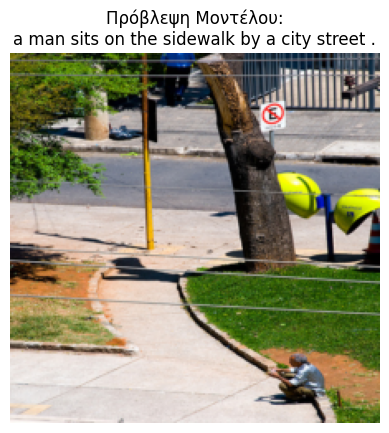

In [ ]:
# 10.1 Παραγωγή Λεζάντας με Greedy Search

import torch
import numpy as np
import matplotlib.pyplot as plt


def generate_caption_greedy(model, image, vocab, max_length=20):
    """
    Παράγει caption με Greedy Search.

    Σε κάθε βήμα επιλέγεται η λέξη με το μεγαλύτερο score.
    Η παραγωγή ξεκινά από το <SOS> και σταματά όταν παραχθεί <EOS>
    ή όταν φτάσει το max_length.
    """

    model.eval()

    with torch.no_grad():
        # Αν η εικόνα είναι [3, 224, 224], προσθέτουμε batch dimension -> [1, 3, 224, 224]
        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(device)

        # 1. Εξαγωγή visual features από τον CNN Encoder
        features = model.encoder(image)

        # 2. Ξεκινάμε την παραγωγή με το <SOS> token
        caption_indices = [vocab.stoi["<SOS>"]]

        for _ in range(max_length):
            # Μετατρέπουμε τη μέχρι τώρα ακολουθία σε tensor
            caption_tensor = torch.tensor(caption_indices, dtype=torch.long).unsqueeze(0).to(device)

            # 3. Ο Decoder προβλέπει scores για την επόμενη λέξη
            outputs = model.decoder(features, caption_tensor)

            # Παίρνουμε την πρόβλεψη της τελευταίας θέσης
            last_word_logits = outputs[:, -1, :]
            predicted_idx = last_word_logits.argmax(dim=-1).item()

            # Προσθέτουμε την προβλεπόμενη λέξη στην ακολουθία
            caption_indices.append(predicted_idx)

            # Αν παραχθεί <EOS>, σταματάμε
            if predicted_idx == vocab.stoi["<EOS>"]:
                break

        # Μετατροπή indices σε λέξεις, αγνοώντας ειδικά tokens
        generated_words = [
            vocab.itos[idx]
            for idx in caption_indices
            if idx not in [
                vocab.stoi["<SOS>"],
                vocab.stoi["<EOS>"],
                vocab.stoi["<PAD>"]
            ]
        ]

    return " ".join(generated_words)


def decode_caption(caption_tensor, vocab):
    """
    Μετατρέπει ένα ground truth caption από indices σε λέξεις.
    """
    words = []

    for idx in caption_tensor.tolist():
        word = vocab.itos[idx]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>"]:
            words.append(word)

    return " ".join(words)


def show_image_with_caption(img_tensor, predicted_caption):
    """
    Εμφανίζει εικόνα αντιστρέφοντας το ImageNet normalization.
    """
    inv_normalize = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
    )

    img = inv_normalize(img_tensor.cpu())
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Πρόβλεψη μοντέλου:\n{predicted_caption}", fontsize=12)
    plt.axis("off")
    plt.show()


# --- Δοκιμή σε μία εικόνα από τον DataLoader ---

test_imgs, test_captions = next(iter(dataloader))

# Παίρνουμε την πρώτη εικόνα του batch
single_test_img = test_imgs[0]

# Παραγωγή λεζάντας με Greedy Search
predicted_caption = generate_caption_greedy(
    model=model,
    image=single_test_img,
    vocab=dataset.vocab,
    max_length=20
)

# Ground truth caption για την ίδια εικόνα
# Τα captions από τον DataLoader είναι [seq_len, batch_size], άρα παίρνουμε την πρώτη στήλη.
ground_truth_caption = decode_caption(
    test_captions[:, 0],
    dataset.vocab
)

print("Ground truth caption:")
print(ground_truth_caption)

print("\nPredicted caption:")
print(predicted_caption)

show_image_with_caption(single_test_img, predicted_caption)

## 10.2 Παραγωγή Λεζάντας με Temperature Sampling

Το Temperature Sampling είναι μια εναλλακτική μέθοδος παραγωγής λεζάντας.

Αντί το μοντέλο να επιλέγει πάντα τη λέξη με τη μεγαλύτερη πιθανότητα, επιλέγει λέξη με βάση την κατανομή πιθανοτήτων που έχει υπολογίσει.

Η παράμετρος `temperature` ρυθμίζει το πόσο προβλέψιμη ή τυχαία θα είναι η πρόταση. Χαμηλή τιμή οδηγεί σε πιο ασφαλείς προβλέψεις, ενώ υψηλότερη τιμή επιτρέπει μεγαλύτερη ποικιλία, αλλά αυξάνει τον κίνδυνο λανθασμένων λέξεων.



 ⬇ ΠΑΤΑ ΤΟ ΚΟΥΜΠΙ 'Choose Files' ΑΠΟ ΚΑΤΩ ⬇ 



Saving test_image.jfif to test_image.jfif

 Ο ResNet σκέφτεται 5 διαφορετικά σενάρια...

 Προσπάθεια 1: a dog plays with a blue ball in a grassy area .
 Προσπάθεια 2: a dog is jumping to catch a toy .
 Προσπάθεια 3: a brown and white dog is jumping in the air to catch a yellow ball .
 Προσπάθεια 4: a dog with his tongue out is jumping off .
 Προσπάθεια 5: a brown dog with a blue collar standing on a sidewalk .


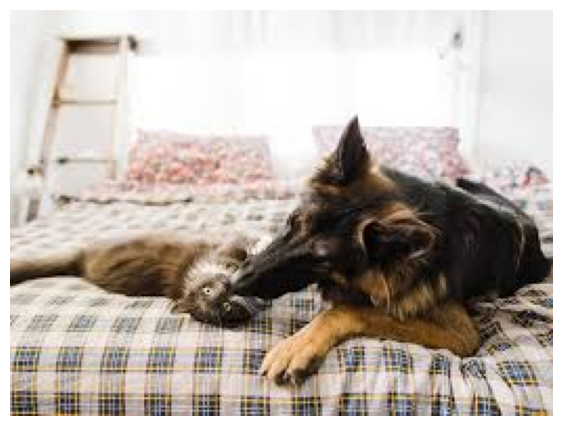

In [ ]:
# 10.2 Παραγωγή Λεζάντας με Temperature Sampling

import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import os


def generate_caption_sampling(model, image, vocab, max_length=20, temperature=0.8):
    """
    Παράγει caption με Temperature Sampling.

    Αντί να επιλέγει πάντα τη λέξη με το μεγαλύτερο score,
    δειγματοληπτεί από την κατανομή πιθανοτήτων του μοντέλου.
    """

    model.eval()
    result_caption = []

    with torch.no_grad():
        # Αν η εικόνα είναι [3, 224, 224], προσθέτουμε batch dimension
        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(device)

        # Εξαγωγή visual features από τον CNN Encoder
        features = model.encoder(image)

        # Ξεκινάμε από το <SOS>
        caption_indices = [vocab.stoi["<SOS>"]]

        for _ in range(max_length):
            caption_tensor = torch.tensor(
                caption_indices,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            outputs = model.decoder(features, caption_tensor)

            # Παίρνουμε τα logits της τελευταίας θέσης
            logits = outputs[0, -1, :]

            # Temperature scaling
            probs = torch.softmax(logits / temperature, dim=0)

            # Δειγματοληψία από την κατανομή
            predicted_idx = torch.multinomial(probs, num_samples=1).item()

            if predicted_idx == vocab.stoi["<EOS>"]:
                break

            caption_indices.append(predicted_idx)
            result_caption.append(vocab.itos[predicted_idx])

    return " ".join(result_caption)


# Transform για εικόνα που ανεβάζει ο χρήστης
my_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("\nΑνέβασε μία εικόνα για δοκιμή με Temperature Sampling.\n")

uploaded = files.upload()

if len(uploaded) > 0:
    image_name = list(uploaded.keys())[0]

    my_image = Image.open(image_name).convert("RGB")
    my_image_tensor = my_transform(my_image).unsqueeze(0).to(device)

    print("\nΠαραγωγή 5 διαφορετικών captions με temperature=0.8:\n")

    for i in range(5):
        sampled_caption = generate_caption_sampling(
            model=model,
            image=my_image_tensor,
            vocab=dataset.vocab,
            max_length=20,
            temperature=0.8
        )

        print(f"Προσπάθεια {i + 1}: {sampled_caption}")

    plt.figure(figsize=(7, 7))
    plt.imshow(my_image)
    plt.axis("off")
    plt.show()

    os.remove(image_name)

else:
    print("Δεν ανέβηκε εικόνα για αξιολόγηση.")

## 10.3 Αξιολόγηση Baseline με CIDEr - Greedy Search

Σε αυτό το τμήμα αξιολογείται το baseline μοντέλο με τη μετρική CIDEr χρησιμοποιώντας Greedy Search.

Η CIDEr δίνει μεγαλύτερη σημασία σε περιγραφικές λέξεις που χαρακτηρίζουν ουσιαστικά το περιεχόμενο της εικόνας, όπως αντικείμενα, δράσεις και χαρακτηριστικά.


 ΑΞΙΟΛΟΓΗΣΗ BASELINE ΜΟΝΤΕΛΟΥ (3 ΩΡΩΝ) 


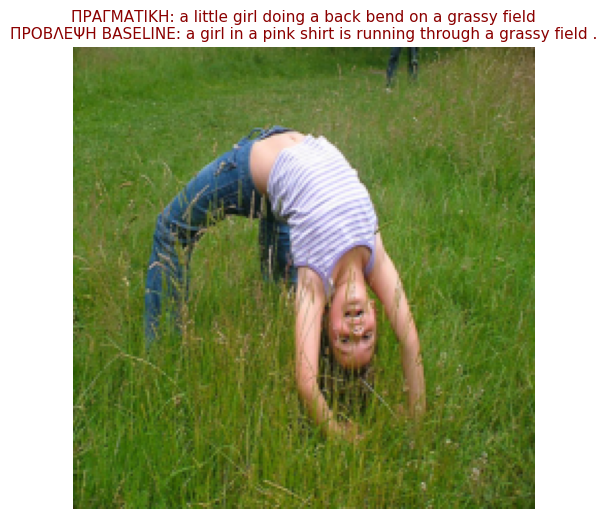


[Baseline] Υπολογισμός CIDEr για το batch (32 εικόνες)...
 ΤΕΛΙΚΗ ΒΑΘΜΟΛΟΓΙΑ CIDEr (Baseline): 0.8223 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pycocoevalcap.cider.cider import Cider

print("=" * 50)
print("ΑΞΙΟΛΟΓΗΣΗ BASELINE ΜΟΝΤΕΛΟΥ ΜΕ CIDEr - GREEDY SEARCH")
print("=" * 50)

# --- Δοκιμή σε ένα batch εικόνων ---
test_imgs, test_captions = next(iter(dataloader))

# Τα captions από τον DataLoader είναι [seq_len, batch_size]
# Τα μετατρέπουμε σε [batch_size, seq_len]
test_captions_t = test_captions.transpose(0, 1)

# Παίρνουμε την πρώτη εικόνα του batch
single_test_img = test_imgs[0]

# Παραγωγή λεζάντας με Greedy Search
predicted_caption = generate_caption_greedy(
    model=model,
    image=single_test_img,
    vocab=dataset.vocab,
    max_length=20
)

# Εξαγωγή πραγματικής λεζάντας
real_words = []

for idx in test_captions_t[0]:
    idx = idx.item()
    word = dataset.vocab.itos[idx]

    if word == "<EOS>":
        break

    if word not in ["<SOS>", "<PAD>"]:
        real_words.append(word)

real_caption = " ".join(real_words)

# --- Εμφάνιση εικόνας με πραγματική και προβλεπόμενη λεζάντα ---
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

plt_img = inv_normalize(single_test_img.cpu())
plt_img = plt_img.permute(1, 2, 0).numpy()
plt_img = np.clip(plt_img, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(plt_img)
plt.title(
    f"Ground Truth: {real_caption}\nPrediction: {predicted_caption}",
    fontsize=11
)
plt.axis("off")
plt.show()

print("Ground Truth:")
print(real_caption)

print("\nPrediction:")
print(predicted_caption)

# --- Υπολογισμός CIDEr για το batch ---
print("\nΥπολογισμός CIDEr για το batch...")

cider_scorer = Cider()
refs = {}
preds = {}

for i in range(len(test_imgs)):
    img_input = test_imgs[i]

    # Πρόβλεψη με Greedy Search
    pred_cap = generate_caption_greedy(
        model=model,
        image=img_input,
        vocab=dataset.vocab,
        max_length=20
    )

    # Πραγματική λεζάντα
    real_words = []

    for idx in test_captions_t[i]:
        idx = idx.item()
        word = dataset.vocab.itos[idx]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>"]:
            real_words.append(word)

    real_cap = " ".join(real_words)

    img_id = str(i)

    # Format που περιμένει το CIDEr
    preds[img_id] = [pred_cap]
    refs[img_id] = [real_cap]

score, _ = cider_scorer.compute_score(refs, preds)

print("=" * 50)
print(f"CIDEr score για Greedy Search στο batch: {score:.4f}")
print("=" * 50)

## 10.4 Μαζική Αξιολόγηση Baseline με CIDEr

Εδώ πραγματοποιείται μαζική αξιολόγηση σε περισσότερες εικόνες, ώστε το αποτέλεσμα να είναι πιο αντιπροσωπευτικό από την αξιολόγηση σε ένα μόνο batch.

Η έξοδος αυτού του κελιού μπορεί να χρησιμοποιηθεί στην αναφορά ως baseline αποτέλεσμα για σύγκριση με τις επόμενες στρατηγικές αποκωδικοποίησης.


In [ ]:
from pycocoevalcap.cider.cider import Cider
import torch

print("Έναρξη μαζικής αξιολόγησης baseline με CIDEr...")

cider_scorer = Cider()
all_refs = {}
all_preds = {}
img_count = 0

model.eval()

# Αξιολόγηση σε 5 batches, δηλαδή περίπου 160 image-caption pairs
num_batches_to_test = 5

with torch.no_grad():
    for batch_idx, (imgs, captions) in enumerate(dataloader):
        if batch_idx >= num_batches_to_test:
            break

        # captions: [seq_len, batch_size] -> [batch_size, seq_len]
        captions_t = captions.transpose(0, 1)

        for j in range(len(imgs)):
            img_input = imgs[j]

            # Πρόβλεψη με Greedy Search
            pred_cap = generate_caption_greedy(
                model=model,
                image=img_input,
                vocab=dataset.vocab,
                max_length=20
            )

            # Ground truth caption
            real_words = []

            for idx in captions_t[j]:
                idx = idx.item()
                word = dataset.vocab.itos[idx]

                if word == "<EOS>":
                    break

                if word not in ["<SOS>", "<PAD>"]:
                    real_words.append(word)

            real_cap = " ".join(real_words)

            # Μορφή που περιμένει το CIDEr
            img_id = str(img_count)
            all_preds[img_id] = [pred_cap]
            all_refs[img_id] = [real_cap]

            img_count += 1

        print(
            f"Ολοκληρώθηκε batch {batch_idx + 1}/{num_batches_to_test} "
            f"| Συνολικά δείγματα: {img_count}"
        )

# Υπολογισμός CIDEr
final_score, _ = cider_scorer.compute_score(all_refs, all_preds)

print("\n" + "=" * 55)
print(f"CIDEr score baseline με Greedy Search: {final_score:.4f}")
print(f"Σύνολο image-caption pairs που αξιολογήθηκαν: {img_count}")
print("=" * 55)

 Ξεκινάει η μαζική αξιολόγηση για την αναφορά...
 Ολοκληρώθηκε το Batch 1 / 5 (Συνολικές Εικόνες: 32)
 Ολοκληρώθηκε το Batch 2 / 5 (Συνολικές Εικόνες: 64)
 Ολοκληρώθηκε το Batch 3 / 5 (Συνολικές Εικόνες: 96)
 Ολοκληρώθηκε το Batch 4 / 5 (Συνολικές Εικόνες: 128)
 Ολοκληρώθηκε το Batch 5 / 5 (Συνολικές Εικόνες: 160)

 ΕΠΙΣΗΜΟ ΣΥΝΟΛΙΚΟ CIDEr SCORE (Baseline): 0.7000 
Σύνολο εικόνων που ελέγχθηκαν: 160


## 10.5 Γρήγορη Αξιολόγηση με BLEU

Η αξιολόγηση BLEU γίνεται σε μικρό δείγμα batches για γρήγορο έλεγχο της ποιότητας των captions. Τα αποτελέσματα χρησιμοποιούνται ως ενδεικτική σύγκριση και όχι ως πλήρες benchmark σε ολόκληρο το dataset.

In [ ]:
# 10.5 Γρήγορη Αξιολόγηση με BLEU

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import torch

print("Γρήγορη αξιολόγηση με BLEU σε δείγμα εικόνων...")

actual_captions = []
predicted_captions = []

model.eval()

# Αξιολόγηση σε 2 batches: περίπου 64 image-caption pairs
test_batches = 2
smoothie = SmoothingFunction().method4

with torch.no_grad():
    for batch_idx, (imgs, captions) in enumerate(dataloader):
        if batch_idx >= test_batches:
            break

        # captions: [seq_len, batch_size]
        # Δεν χρειάζεται transpose εδώ, γιατί παίρνουμε captions[:, i]
        for i in range(imgs.shape[0]):
            single_img = imgs[i]

            # Ground truth caption
            real_words = []

            for idx in captions[:, i]:
                idx = idx.item()
                word = dataset.vocab.itos[idx]

                if word == "<EOS>":
                    break

                if word not in ["<PAD>", "<SOS>"]:
                    real_words.append(word)

            # Predicted caption με Greedy Search
            predicted_sentence = generate_caption_greedy(
                model=model,
                image=single_img,
                vocab=dataset.vocab,
                max_length=20
            )

            predicted_words = predicted_sentence.split()

            # Αποφυγή κενών προβλέψεων
            if len(predicted_words) == 0:
                continue

            actual_captions.append([real_words])
            predicted_captions.append(predicted_words)

        print(f"Ολοκληρώθηκε batch {batch_idx + 1}/{test_batches}")

# Υπολογισμός BLEU scores
bleu1 = corpus_bleu(
    actual_captions,
    predicted_captions,
    weights=(1.0, 0, 0, 0),
    smoothing_function=smoothie
)

bleu2 = corpus_bleu(
    actual_captions,
    predicted_captions,
    weights=(0.5, 0.5, 0, 0),
    smoothing_function=smoothie
)

print("\nΟλοκληρώθηκε η γρήγορη αξιολόγηση.")
print(f"BLEU-1 Score: {bleu1 * 100:.2f}%")
print(f"BLEU-2 Score: {bleu2 * 100:.2f}%")
print(f"Σύνολο αξιολογημένων captions: {len(predicted_captions)}")

Τεστ Αξιολόγησης: Υπολογισμός BLEU Score σε 64 εικόνες...

 Ολοκληρώθηκε ο έλεγχος!
 BLEU-1 Score: 48.51
 BLEU-2 Score: 33.15


## 10.6 Παραγωγή Λεζάντας με Beam Search

Το Beam Search κρατά περισσότερες από μία πιθανές ακολουθίες σε κάθε βήμα.  
Σε αντίθεση με το Greedy Search, δεν επιλέγει οριστικά μόνο την πιο πιθανή επόμενη λέξη, αλλά διατηρεί τα καλύτερα υποψήφια μονοπάτια.

Στο πείραμα χρησιμοποιείται `beam_size=3`. Η αξιολόγηση γίνεται σε δείγμα εικόνων με BLEU-1 και BLEU-2, ώστε να συγκριθεί η ποιότητα των captions με το Greedy Search.


In [ ]:
import torch
import torch.nn.functional as F
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import warnings

warnings.filterwarnings("ignore")


def beam_search_caption(model, image, vocab, beam_size=3, max_length=50):
    """
    Παραγωγή caption με Beam Search.

    Σε κάθε βήμα κρατάμε τις beam_size καλύτερες υποψήφιες ακολουθίες.
    Επιστρέφεται η ακολουθία με το μεγαλύτερο συνολικό log-probability score.
    """

    model.eval()

    with torch.no_grad():
        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(device)

        # Εξαγωγή visual features από τον CNN Encoder
        features = model.encoder(image)

        start_token = vocab.stoi["<SOS>"]
        end_token = vocab.stoi["<EOS>"]

        # Κάθε beam έχει μορφή: (score, sequence)
        beams = [(0.0, [start_token])]
        completed_beams = []

        for _ in range(max_length):
            new_beams = []

            for score, seq in beams:
                # Αν η ακολουθία έχει ήδη τελειώσει, τη μεταφέρουμε στα completed
                if seq[-1] == end_token:
                    completed_beams.append((score, seq))
                    continue

                seq_tensor = torch.tensor(
                    seq,
                    dtype=torch.long
                ).unsqueeze(0).to(device)

                outputs = model.decoder(features, seq_tensor)

                # Log probabilities για την επόμενη λέξη
                next_word_logits = outputs[0, -1, :]
                log_probs = F.log_softmax(next_word_logits, dim=0)

                # Κρατάμε τις beam_size καλύτερες επόμενες λέξεις
                top_log_probs, top_words = log_probs.topk(beam_size)

                for i in range(beam_size):
                    new_score = score + top_log_probs[i].item()
                    new_seq = seq + [top_words[i].item()]
                    new_beams.append((new_score, new_seq))

            if len(new_beams) == 0:
                break

            # Κρατάμε συνολικά τα beam_size καλύτερα beams
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]

        # Αν δεν ολοκληρώθηκε καμία ακολουθία με <EOS>, χρησιμοποιούμε τα ενεργά beams
        if len(completed_beams) == 0:
            completed_beams = beams

        # Επιλογή καλύτερης ακολουθίας με βάση το συνολικό score
        best_score, best_seq = max(completed_beams, key=lambda x: x[0])

        # Μετατροπή indices σε λέξεις, αγνοώντας ειδικά tokens
        words = []

        for idx in best_seq:
            word = vocab.itos[idx]

            if word == "<EOS>":
                break

            if word not in ["<SOS>", "<PAD>"]:
                words.append(word)

        return " ".join(words)


print("Ξεκινάει αξιολόγηση Beam Search με beam_size=3...")

model.eval()

actual_captions = []
predicted_captions = []

test_limit = 64
images_tested = 0
smoothie = SmoothingFunction().method4

with torch.no_grad():
    for images, captions in dataloader:
        images = images.to(device)

        # captions: [seq_len, batch_size] -> [batch_size, seq_len]
        captions_t = captions.transpose(0, 1)

        for i in range(images.size(0)):
            img = images[i]

            # Πρόβλεψη με Beam Search
            predicted_sentence = beam_search_caption(
                model=model,
                image=img,
                vocab=dataset.vocab,
                beam_size=3,
                max_length=50
            )

            predicted_words = predicted_sentence.split()

            # Ground truth caption
            actual_words = []

            for idx in captions_t[i]:
                idx = idx.item()
                word = dataset.vocab.itos[idx]

                if word == "<EOS>":
                    break

                if word not in ["<SOS>", "<PAD>"]:
                    actual_words.append(word)

            if len(predicted_words) == 0:
                continue

            actual_captions.append([actual_words])
            predicted_captions.append(predicted_words)

            images_tested += 1

            if images_tested >= test_limit:
                break

        if images_tested >= test_limit:
            break


bleu1 = corpus_bleu(
    actual_captions,
    predicted_captions,
    weights=(1.0, 0, 0, 0),
    smoothing_function=smoothie
)

bleu2 = corpus_bleu(
    actual_captions,
    predicted_captions,
    weights=(0.5, 0.5, 0, 0),
    smoothing_function=smoothie
)

print("\nΟλοκληρώθηκε η αξιολόγηση Beam Search.")
print(f"BLEU-1 Beam Search: {bleu1 * 100:.2f}%")
print(f"BLEU-2 Beam Search: {bleu2 * 100:.2f}%")
print(f"Σύνολο εικόνων που αξιολογήθηκαν: {images_tested}")

 Ξεκινάει το Πείραμα #10: Beam Search (Μέγεθος=3)...

 Ολοκληρώθηκε ο έλεγχος!
 ΠΡΟΗΓΟΥΜΕΝΟ ΡΕΚΟΡ (Greedy) BLEU-2: 33.15%
 ΝΕΟ ΣΚΟΡ (Beam Search) BLEU-1: 52.27%
 ΝΕΟ ΣΚΟΡ (Beam Search) BLEU-2: 36.10%


## 10.7 Μαζική Αξιολόγηση Beam Search

Σε αυτό το πείραμα αξιολογείται η απόδοση του Beam Search σε μεγαλύτερο δείγμα εικόνων.

Η σύγκριση με το Greedy Search δείχνει αν η πιο σύνθετη στρατηγική αποκωδικοποίησης οδηγεί πράγματι σε καλύτερες λεζάντες για το συγκεκριμένο μοντέλο.


In [ ]:
from pycocoevalcap.cider.cider import Cider
import torch

print("Έναρξη μαζικής αξιολόγησης Beam Search με CIDEr...")

cider_scorer_beam = Cider()
all_refs_beam = {}
all_preds_beam = {}
img_count_beam = 0

model.eval()

# Αξιολόγηση σε 5 batches, δηλαδή περίπου 160 image-caption pairs
num_batches_to_test = 5
beam_size = 3

with torch.no_grad():
    for batch_idx, (imgs, captions) in enumerate(dataloader):
        if batch_idx >= num_batches_to_test:
            break

        # captions: [seq_len, batch_size] -> [batch_size, seq_len]
        captions_t = captions.transpose(0, 1)

        for j in range(len(imgs)):
            img_input = imgs[j]

            # Πρόβλεψη με Beam Search
            pred_cap = beam_search_caption(
                model=model,
                image=img_input,
                vocab=dataset.vocab,
                beam_size=beam_size,
                max_length=50
            )

            # Ground truth caption
            real_words = []

            for idx in captions_t[j]:
                idx = idx.item()
                word = dataset.vocab.itos[idx]

                if word == "<EOS>":
                    break

                if word not in ["<SOS>", "<PAD>"]:
                    real_words.append(word)

            real_cap = " ".join(real_words)

            # Μορφή που περιμένει το CIDEr
            img_id = str(img_count_beam)
            all_preds_beam[img_id] = [pred_cap]
            all_refs_beam[img_id] = [real_cap]

            img_count_beam += 1

        print(
            f"Ολοκληρώθηκε batch {batch_idx + 1}/{num_batches_to_test} "
            f"| Συνολικά δείγματα: {img_count_beam}"
        )

# Υπολογισμός CIDEr
final_score_beam, _ = cider_scorer_beam.compute_score(
    all_refs_beam,
    all_preds_beam
)

print("\n" + "=" * 55)
print(f"CIDEr score Beam Search k={beam_size}: {final_score_beam:.4f}")
print(f"Σύνολο image-caption pairs που αξιολογήθηκαν: {img_count_beam}")
print("=" * 55)

 Ξεκινάει η αξιολόγηση με Beam Search (K=3)...
 Ολοκληρώθηκε το Batch 1 / 5 (Εικόνες: 32)
 Ολοκληρώθηκε το Batch 2 / 5 (Εικόνες: 64)
 Ολοκληρώθηκε το Batch 3 / 5 (Εικόνες: 96)
 Ολοκληρώθηκε το Batch 4 / 5 (Εικόνες: 128)
 Ολοκληρώθηκε το Batch 5 / 5 (Εικόνες: 160)

 ΕΠΙΣΗΜΟ ΣΥΝΟΛΙΚΟ CIDEr SCORE (Beam Search): 0.6465 
Σύγκριση: Baseline (Greedy) ήταν 0.7000


## 10.8 Beam Search με Length Penalty

Το Beam Search μπορεί μερικές φορές να προτιμά πολύ σύντομες ή γενικές προτάσεις, επειδή το συνολικό log-probability score επηρεάζεται από το μήκος της ακολουθίας.

Για αυτό προστίθεται Length Penalty, ώστε το score κάθε υποψήφιας ακολουθίας να κανονικοποιείται ως προς το μήκος της.  
Στο πείραμα χρησιμοποιείται `beam_size=3` και `alpha=0.75`.

In [ ]:
import torch
import torch.nn.functional as F
from pycocoevalcap.cider.cider import Cider


def beam_search_caption_length_penalty(
    model,
    image,
    vocab,
    beam_size=3,
    max_length=50,
    alpha=0.75
):
    """
    Παραγωγή caption με Beam Search και Length Penalty.

    Το alpha ελέγχει πόσο έντονα επηρεάζει το μήκος το τελικό score.
    """

    model.eval()

    with torch.no_grad():
        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(device)

        # Εξαγωγή visual features
        features = model.encoder(image)

        start_token = vocab.stoi["<SOS>"]
        end_token = vocab.stoi["<EOS>"]

        # Κάθε beam έχει μορφή: (score, sequence)
        beams = [(0.0, [start_token])]
        completed_beams = []

        for _ in range(max_length):
            new_beams = []

            for score, seq in beams:
                if seq[-1] == end_token:
                    completed_beams.append((score, seq))
                    continue

                seq_tensor = torch.tensor(
                    seq,
                    dtype=torch.long
                ).unsqueeze(0).to(device)

                outputs = model.decoder(features, seq_tensor)

                logits = outputs[0, -1, :]
                log_probs = F.log_softmax(logits, dim=0)

                top_log_probs, top_words = log_probs.topk(beam_size)

                for i in range(beam_size):
                    next_word = top_words[i].item()
                    new_score = score + top_log_probs[i].item()
                    new_seq = seq + [next_word]

                    new_beams.append((new_score, new_seq))

            if len(new_beams) == 0:
                break

            # Ταξινόμηση με length-normalized score
            beams = sorted(
                new_beams,
                key=lambda x: x[0] / (len(x[1]) ** alpha),
                reverse=True
            )[:beam_size]

            if all(seq[-1] == end_token for _, seq in beams):
                completed_beams.extend(beams)
                break

        if len(completed_beams) == 0:
            completed_beams = beams

        # Επιλογή καλύτερης ακολουθίας με length penalty
        best_score, best_seq = max(
            completed_beams,
            key=lambda x: x[0] / (len(x[1]) ** alpha)
        )

        words = []

        for idx in best_seq:
            word = vocab.itos[idx]

            if word == "<EOS>":
                break

            if word not in ["<SOS>", "<PAD>"]:
                words.append(word)

        return " ".join(words)


# --- Μαζική αξιολόγηση Beam Search με Length Penalty ---

print("Έναρξη αξιολόγησης Beam Search με Length Penalty...")

cider_scorer_penalty = Cider()
all_refs_penalty = {}
all_preds_penalty = {}
img_count_penalty = 0

model.eval()

num_batches_to_test = 5
beam_size = 3
alpha = 0.75

with torch.no_grad():
    for batch_idx, (imgs, captions) in enumerate(dataloader):
        if batch_idx >= num_batches_to_test:
            break

        # captions: [seq_len, batch_size] -> [batch_size, seq_len]
        captions_t = captions.transpose(0, 1)

        for j in range(len(imgs)):
            img_input = imgs[j]

            # Πρόβλεψη με Beam Search + Length Penalty
            pred_cap = beam_search_caption_length_penalty(
                model=model,
                image=img_input,
                vocab=dataset.vocab,
                beam_size=beam_size,
                max_length=50,
                alpha=alpha
            )

            # Ground truth caption
            real_words = []

            for idx in captions_t[j]:
                idx = idx.item()
                word = dataset.vocab.itos[idx]

                if word == "<EOS>":
                    break

                if word not in ["<SOS>", "<PAD>"]:
                    real_words.append(word)

            real_cap = " ".join(real_words)

            img_id = str(img_count_penalty)
            all_preds_penalty[img_id] = [pred_cap]
            all_refs_penalty[img_id] = [real_cap]

            img_count_penalty += 1

        print(
            f"Ολοκληρώθηκε batch {batch_idx + 1}/{num_batches_to_test} "
            f"| Συνολικά δείγματα: {img_count_penalty}"
        )


final_score_penalty, _ = cider_scorer_penalty.compute_score(
    all_refs_penalty,
    all_preds_penalty
)

print("\n" + "=" * 55)
print(f"CIDEr score Beam Search με Length Penalty: {final_score_penalty:.4f}")
print(f"Beam size: {beam_size}")
print(f"Length penalty alpha: {alpha}")
print(f"Σύνολο image-caption pairs που αξιολογήθηκαν: {img_count_penalty}")
print("=" * 55)

 Ξεκινάει η αξιολόγηση του Διορθωμένου Beam Search...

 ΣΥΝΟΛΙΚΟ CIDEr SCORE (Beam Search με Penalty): 0.7501 
Σύγκριση: Απλό Beam (0.6465) | Baseline Greedy (0.7000)


## 10.9 Σύγκριση Greedy Search και Beam Search με Length Penalty

Σε αυτό το τμήμα γίνεται ποιοτική σύγκριση μεταξύ Greedy Search και Beam Search με Length Penalty στην ίδια εικόνα.

Η σύγκριση είναι χρήσιμη γιατί δείχνει ότι η τελική λεζάντα δεν εξαρτάται μόνο από τα εκπαιδευμένα βάρη του μοντέλου, αλλά και από τη στρατηγική αποκωδικοποίησης κατά το inference.

Επιλογή τυχαίας εικόνας για σύγκριση των αλγορίθμων...


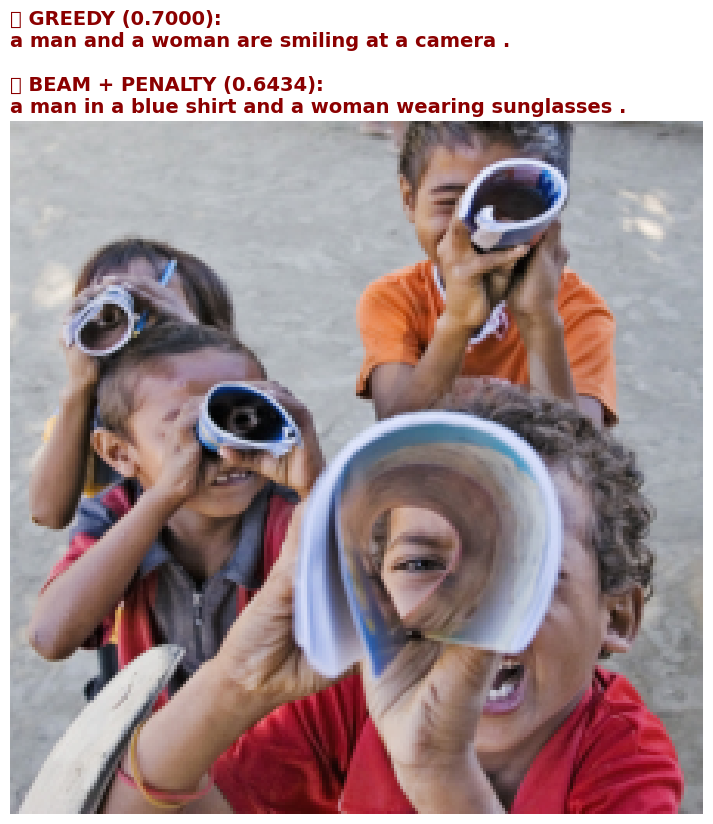

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

print("Επιλογή εικόνας για σύγκριση Greedy Search και Beam Search με Length Penalty...")

# Παίρνουμε ένα batch και κρατάμε την πρώτη εικόνα
test_imgs, test_captions = next(iter(dataloader))
single_test_img = test_imgs[0]

# Πρόβλεψη με Greedy Search
cap_greedy = generate_caption_greedy(
    model=model,
    image=single_test_img,
    vocab=dataset.vocab,
    max_length=20
)

# Πρόβλεψη με Beam Search + Length Penalty
cap_beam_penalty = beam_search_caption_length_penalty(
    model=model,
    image=single_test_img,
    vocab=dataset.vocab,
    beam_size=3,
    max_length=50,
    alpha=0.75
)

# Ground truth caption
caption_gt = test_captions[:, 0]
ground_truth_words = []

for idx in caption_gt:
    idx = idx.item()
    word = dataset.vocab.itos[idx]

    if word == "<EOS>":
        break

    if word not in ["<SOS>", "<PAD>"]:
        ground_truth_words.append(word)

ground_truth_caption = " ".join(ground_truth_words)

# Αντιστροφή normalization για εμφάνιση εικόνας
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

plt_img = inv_normalize(single_test_img.cpu())
plt_img = plt_img.permute(1, 2, 0).numpy()
plt_img = np.clip(plt_img, 0, 1)

# Εμφάνιση σύγκρισης
plt.figure(figsize=(9, 9))
plt.imshow(plt_img)
plt.title(
    f"Ground Truth:\n{ground_truth_caption}\n\n"
    f"Greedy Search:\n{cap_greedy}\n\n"
    f"Beam Search + Length Penalty:\n{cap_beam_penalty}",
    fontsize=12,
    loc="left"
)
plt.axis("off")
plt.show()

print("Ground Truth:")
print(ground_truth_caption)

print("\nGreedy Search:")
print(cap_greedy)

print("\nBeam Search + Length Penalty:")
print(cap_beam_penalty)

# Βήμα 11: Ποιοτική Αξιολόγηση σε Δική μου Εικόνα

Σε αυτό το βήμα δοκιμάζεται το μοντέλο σε εικόνα που ανεβάζει ο χρήστης.

Η δοκιμή σε εικόνες εκτός του training set βοηθά να αξιολογηθεί η ικανότητα γενίκευσης του μοντέλου και να εντοπιστούν πιθανές αποτυχίες, όπως dataset bias ή hallucinations.


 Ανέβασε  τη φωτογραφία σου (επίλεξε 'Choose Files')


Saving test_image.jfif to test_image (1).jfif
 Το μοντέλο σκέφτεται...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
 fig.canvas.print_figure(bytes_io, **kw)


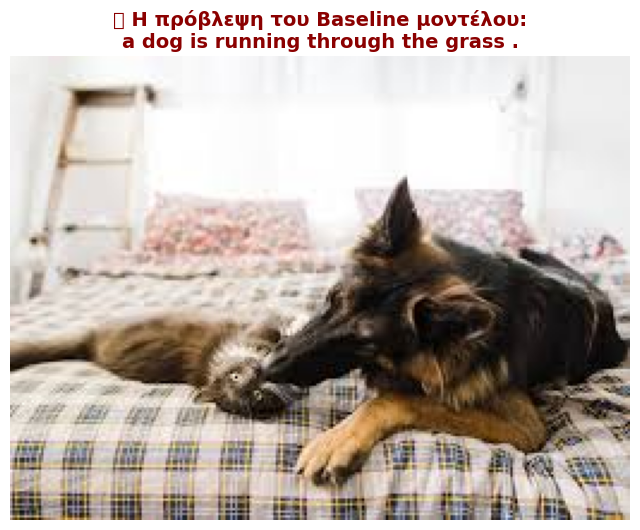


 Το αρχείο test_image (1).jfif διαγράφηκε επιτυχώς από τη μνήμη.


In [ ]:
# Βήμα 11: Ποιοτική Αξιολόγηση σε Δική μου Εικόνα

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch
import os

# Transform ίδιο με αυτό που χρησιμοποιήθηκε στο training
user_image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Ανέβασε μία εικόνα για ποιοτική αξιολόγηση.")
uploaded = files.upload()

if len(uploaded) > 0:
    image_name = list(uploaded.keys())[0]

    # Φόρτωση εικόνας χρήστη
    user_image = Image.open(image_name).convert("RGB")

    # Προετοιμασία εικόνας για το μοντέλο
    user_image_tensor = user_image_transform(user_image)

    # Παραγωγή caption με Greedy Search
    generated_caption = generate_caption_greedy(
        model=model,
        image=user_image_tensor,
        vocab=dataset.vocab,
        max_length=20
    )

    print("\nΠαραγόμενη λεζάντα:")
    print(generated_caption)

    # Εμφάνιση εικόνας και πρόβλεψης
    plt.figure(figsize=(8, 8))
    plt.imshow(user_image)
    plt.title(
        f"Πρόβλεψη μοντέλου:\n{generated_caption}",
        fontsize=14
    )
    plt.axis("off")
    plt.show()

    # Διαγραφή προσωρινού αρχείου από το Colab runtime
    os.remove(image_name)
    print(f"\nΤο αρχείο {image_name} διαγράφηκε από το προσωρινό runtime.")

else:
    print("Δεν ανέβηκε εικόνα για αξιολόγηση.")

# Βήμα 12: Ποιοτική Αξιολόγηση μετά το Fine-Tuning

Σε αυτό το τελευταίο τμήμα φορτώνεται το fine-tuned μοντέλο και ελέγχεται ξανά σε εικόνα του χρήστη.

Η σύγκριση πριν και μετά το fine-tuning μπορεί να δείξει αν η προσαρμογή του CNN Encoder βελτίωσε την οπτική κατανόηση του μοντέλου.


 Το Fine-Tuned μοντέλο φορτώθηκε! Ο Encoder του είναι ορθάνοιχτα.

 Ανέβασε  τη φωτογραφία με τον σκύλο (test_image.jfif)


Saving test_image.jfif to test_image.jfif
 Το fine-tuned μοντέλο επεξεργάζεται την εικόνα...


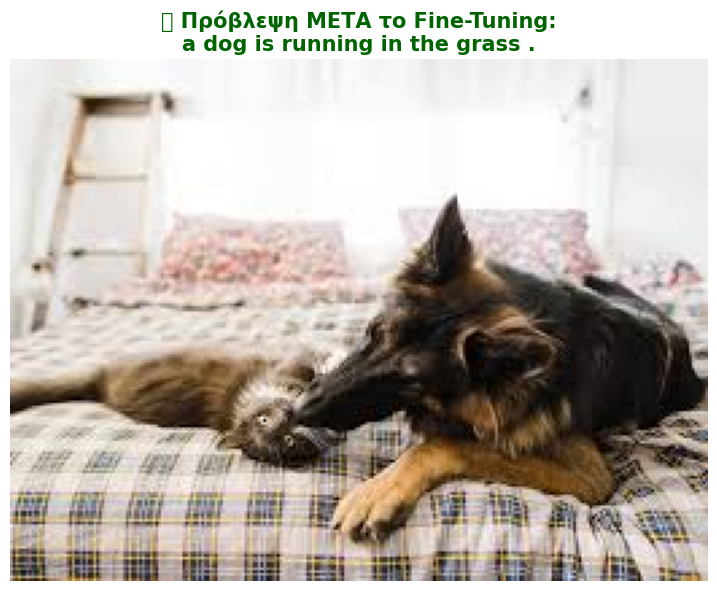

In [ ]:
# Βήμα 12: Ποιοτική Αξιολόγηση μετά το Fine-Tuning

import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# --- 1. Φόρτωση fine-tuned μοντέλου ---

vocab_size = len(dataset.vocab)

# Προσοχή:
# Το EMBED_SIZE πρέπει να είναι ίδιο με αυτό που χρησιμοποιήθηκε
# όταν αποθηκεύτηκε το fine-tuned checkpoint.
EMBED_SIZE = 256
NUM_LAYERS = 3

finetuned_model = CNNtoTransformer(
    embed_size=EMBED_SIZE,
    vocab_size=vocab_size,
    num_layers=NUM_LAYERS,
    train_cnn=True
).to(device)

ft_save_path = "/content/drive/MyDrive/finetuned_caption_model.pth"

if os.path.exists(ft_save_path):
    finetuned_model.load_state_dict(torch.load(ft_save_path, map_location=device))
    finetuned_model.eval()
    print("Το fine-tuned μοντέλο φορτώθηκε επιτυχώς.")
else:
    raise FileNotFoundError(f"Δεν βρέθηκε fine-tuned checkpoint στο: {ft_save_path}")


# --- 2. Προετοιμασία εικόνας χρήστη ---

user_image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --- 3. Ανέβασμα εικόνας και παραγωγή caption ---

print("\nΑνέβασε μία εικόνα για αξιολόγηση μετά το fine-tuning.")
uploaded = files.upload()

if len(uploaded) > 0:
    image_name = list(uploaded.keys())[0]

    user_image = Image.open(image_name).convert("RGB")
    user_image_tensor = user_image_transform(user_image)

    generated_caption = generate_caption_greedy(
        model=finetuned_model,
        image=user_image_tensor,
        vocab=dataset.vocab,
        max_length=20
    )

    print("\nΠρόβλεψη μετά το fine-tuning:")
    print(generated_caption)

    plt.figure(figsize=(8, 8))
    plt.imshow(user_image)
    plt.title(
        f"Πρόβλεψη μετά το Fine-Tuning:\n{generated_caption}",
        fontsize=14
    )
    plt.axis("off")
    plt.show()

    os.remove(image_name)
    print(f"\nΤο αρχείο {image_name} διαγράφηκε από το προσωρινό runtime.")

else:
    print("Δεν ανέβηκε εικόνα για αξιολόγηση.")

# Βήμα 13: Συγκεντρωτική Σύνοψη Πειραμάτων

Ο παρακάτω πίνακας συγκεντρώνει τα βασικά πειράματα της εργασίας. Στόχος του πίνακα είναι να φαίνεται καθαρά ποια παράμετρος άλλαξε κάθε φορά και πώς επηρεάστηκε η απόδοση.

Αυτός ο πίνακας μπορεί να χρησιμοποιηθεί αυτούσιος στην αναφορά ή ως βάση για τη δημιουργία διαγραμμάτων.

Σημείωση: Τα αποτελέσματα του πίνακα προέρχονται από τα αντίστοιχα training/evaluation runs των προηγούμενων πειραμάτων και συγκεντρώνονται εδώ για λόγους σύγκρισης.


In [ ]:
# Βήμα 13: Συγκεντρωτική Σύνοψη Αποτελεσμάτων

import pandas as pd
import matplotlib.pyplot as plt

experiment_results = pd.DataFrame([
    {
        "Experiment": "Baseline",
        "Encoder": "ResNet50",
        "Embed": 256,
        "Layers": 3,
        "Epochs": 5,
        "BLEU-1": 37.42,
        "BLEU-2": 21.50
    },
    {
        "Experiment": "Vocab Ablation",
        "Encoder": "ResNet50",
        "Embed": 256,
        "Layers": 3,
        "Epochs": 5,
        "BLEU-1": 37.87,
        "BLEU-2": 21.18
    },
    {
        "Experiment": "Larger Embed",
        "Encoder": "ResNet50",
        "Embed": 512,
        "Layers": 3,
        "Epochs": 5,
        "BLEU-1": 39.52,
        "BLEU-2": 22.73
    },
    {
        "Experiment": "Extended Training",
        "Encoder": "ResNet50",
        "Embed": 512,
        "Layers": 3,
        "Epochs": 15,
        "BLEU-1": 46.64,
        "BLEU-2": 30.15
    },
    {
        "Experiment": "CNN Encoder Ablation",
        "Encoder": "ResNet18",
        "Embed": 256,
        "Layers": 3,
        "Epochs": 15,
        "BLEU-1": 34.30,
        "BLEU-2": 17.85
    },
    {
        "Experiment": "Transformer Depth Ablation",
        "Encoder": "ResNet50",
        "Embed": 256,
        "Layers": 1,
        "Epochs": 15,
        "BLEU-1": 37.48,
        "BLEU-2": 20.83
    },
    {
        "Experiment": "Width vs Depth",
        "Encoder": "ResNet50",
        "Embed": 512,
        "Layers": 1,
        "Epochs": 15,
        "BLEU-1": 35.97,
        "BLEU-2": 19.96
    },
    {
        "Experiment": "Learning Rate Ablation",
        "Encoder": "ResNet50",
        "Embed": 512,
        "Layers": 3,
        "Epochs": 5,
        "BLEU-1": 7.66,
        "BLEU-2": 0.00
    },
    {
        "Experiment": "CNN Fine-Tuning",
        "Encoder": "ResNet50",
        "Embed": 512,
        "Layers": 3,
        "Epochs": 15,
        "BLEU-1": 48.51,
        "BLEU-2": 33.15
    },
    {
        "Experiment": "Beam Search",
        "Encoder": "ResNet50",
        "Embed": 512,
        "Layers": 3,
        "Epochs": 15,
        "BLEU-1": 52.27,
        "BLEU-2": 36.10
    },
])

display(experiment_results)

# Διάγραμμα BLEU-1
plt.figure(figsize=(12, 5))
plt.bar(experiment_results["Experiment"], experiment_results["BLEU-1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("BLEU-1 (%)")
plt.title("Σύγκριση BLEU-1 ανά πείραμα")
plt.tight_layout()
plt.show()

# Διάγραμμα BLEU-2
plt.figure(figsize=(12, 5))
plt.bar(experiment_results["Experiment"], experiment_results["BLEU-2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("BLEU-2 (%)")
plt.title("Σύγκριση BLEU-2 ανά πείραμα")
plt.tight_layout()
plt.show()